In [1]:
from modeling.tree_models import build_random_forest, build_xgboost
from modeling.regression_models import build_logistic_regression
from modeling.dnn_models import build_simple_dnn
from modeling.base_model import train_model, predict_model, predict_proba_model
from modeling.evaluate import evaluate_classification, plot_confusion, plot_roc
import pandas as pd

In [2]:
# Load resampled dataset
df_encoded = pd.read_csv('../data/processed/df_encoded_resampled.csv')
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
print(f"Features shape: {X.shape} | Target shape: {y.shape}")

Features shape: (10348, 38) | Target shape: (10348,)


In [3]:
from sklearn.model_selection import train_test_split
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

## Random forest

Model trained.
Accuracy: 0.849 | Precision: 0.832 | Recall: 0.873 | F1: 0.852
ROC AUC: 0.922


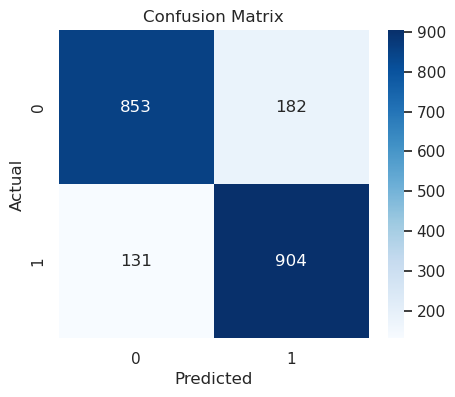

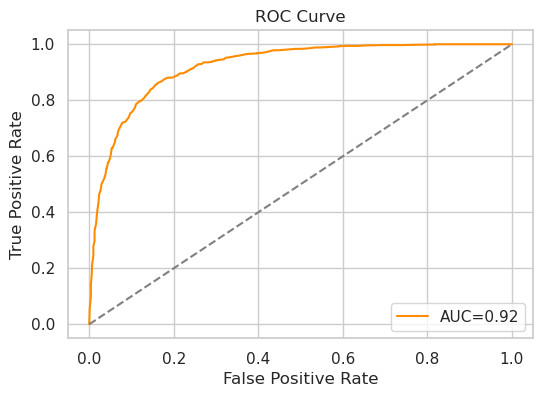

In [4]:
model_rf = build_random_forest(n_estimators=100, random_state=42)
model_rf = train_model(model_rf, X_train, y_train)
y_pred_rf = predict_model(model_rf, X_test)
y_proba_rf = predict_proba_model(model_rf, X_test)
metrics_rf = evaluate_classification(y_test, y_pred_rf, y_proba_rf)
plot_confusion(y_test, y_pred_rf)
plot_roc(y_test, y_proba_rf)

## XGBoost

/home/thabo/anaconda3/envs/customer-churn-env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:46:59] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1744329020674/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model trained.
Accuracy: 0.849 | Precision: 0.832 | Recall: 0.873 | F1: 0.852
ROC AUC: 0.922


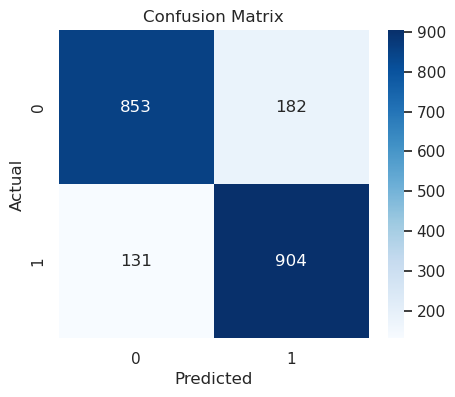

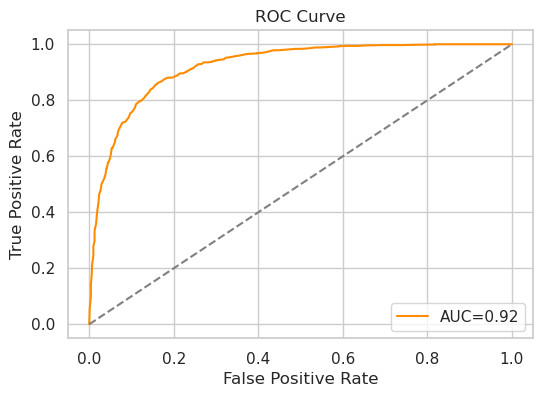

In [5]:
model_xgb = build_xgboost()
model_xgb = train_model(model_xgb, X_train, y_train)
y_pred_rf = predict_model(model_rf, X_test)
y_proba_rf = predict_proba_model(model_rf, X_test)
metrics_rf = evaluate_classification(y_test, y_pred_rf, y_proba_rf)
plot_confusion(y_test, y_pred_rf)
plot_roc(y_test, y_proba_rf)

## Logistic regression

Model trained.
Accuracy: 0.849 | Precision: 0.832 | Recall: 0.873 | F1: 0.852
ROC AUC: 0.922


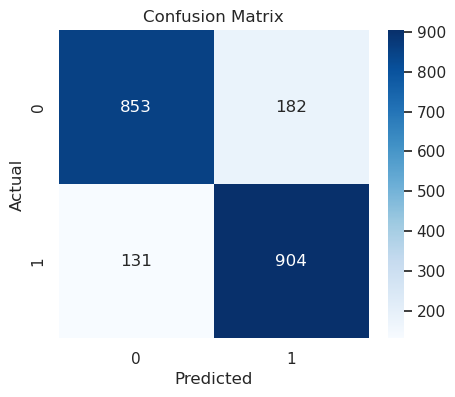

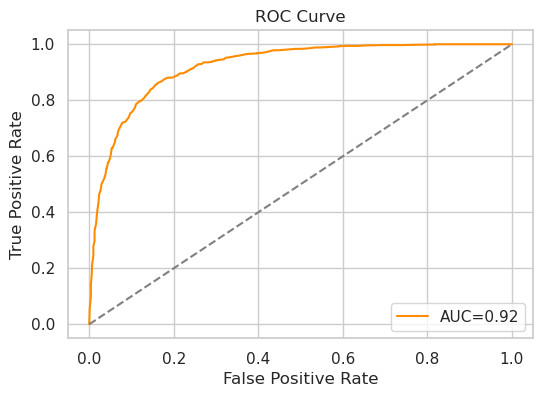

In [6]:
from sklearn.linear_model import LogisticRegression

def build_logistic_regression():
    return LogisticRegression(max_iter=10000)

model_lr = build_logistic_regression()
model_lr = train_model(model_lr, X_train, y_train)
y_pred_rf = predict_model(model_rf, X_test)
y_proba_rf = predict_proba_model(model_rf, X_test)
metrics_rf = evaluate_classification(y_test, y_pred_rf, y_proba_rf)
plot_confusion(y_test, y_pred_rf)
plot_roc(y_test, y_proba_rf)

## DNN

Epoch 1/10


/home/thabo/anaconda3/envs/customer-churn-env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6947 - loss: 0.5864 - val_accuracy: 0.7560 - val_loss: 0.4821
Epoch 2/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step - accuracy: 0.7818 - loss: 0.4782 - val_accuracy: 0.7572 - val_loss: 0.4772
Epoch 3/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.7885 - loss: 0.4466 - val_accuracy: 0.7681 - val_loss: 0.4650
Epoch 4/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - accuracy: 0.8097 - loss: 0.4327 - val_accuracy: 0.7645 - val_loss: 0.4586
Epoch 5/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - accuracy: 0.7972 - loss: 0.4348 - val_accuracy: 0.7766 - val_loss: 0.4493
Epoch 6/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step - accuracy: 0.8091 - loss: 0.4283 - val_accuracy: 0.7862 - val_loss: 0.4512
Epoch 7/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.8074 - loss: 0.4153 - val_accuracy: 0.7814 - val_loss: 0.4408
Epoch 8/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - accuracy: 0.8137 - loss: 0.4084 - val_accuracy:

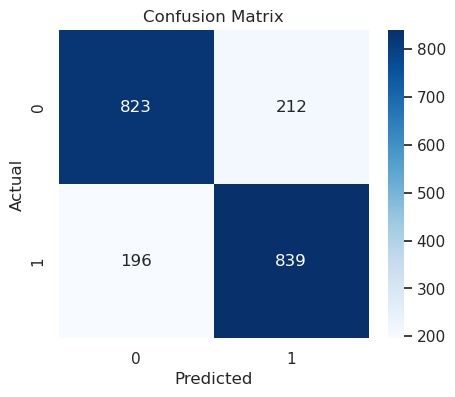

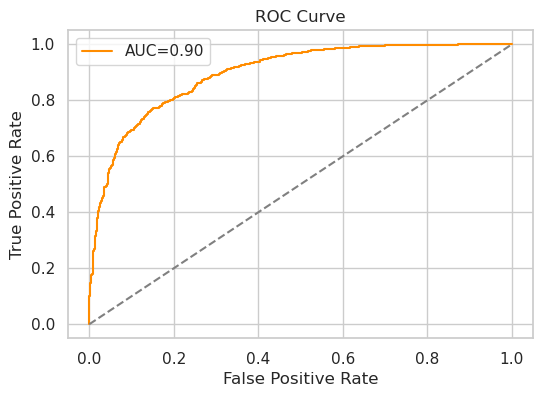

In [7]:
from sklearn.preprocessing import StandardScaler

# Scale data for DNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_dnn = build_simple_dnn(input_dim=X_train_scaled.shape[1])
model_dnn.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_split=0.1)
y_pred_dnn = (model_dnn.predict(X_test_scaled) > 0.5).astype(int)
# No ROC curve: keras predict returns probabilities, so you can do it
y_proba_dnn = model_dnn.predict(X_test_scaled)
metrics_dnn = evaluate_classification(y_test, y_pred_dnn, y_proba_dnn)
plot_confusion(y_test, y_pred_dnn)
plot_roc(y_test, y_proba_dnn)